# Attribute 10 - Ecosystem 15% Cover Goal
#### Rationale:
Highlights ecosystem types that are below 15% of their expected land cover within each catchment.


#### Data layers
Ecoindex RTZ layer

#### Scoring
Raster attribute table:

| PixelScore | PixelDesc         | 
|-------|------------------------|
| 0     | Otherwise              |
| 10    | Ecosystems under 15%   |



In [2]:
import json
import math
import os
from os import listdir


import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pyproj
import rasterio 
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from shapely.geometry import Point, Polygon, box

import numpy as np
from osgeo import gdal
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
from shapely.geometry import shape

from constants import small_polygon_threshold, m2_to_ha, x_resolution, y_resolution, keep_cols, keep_cols_catch

# Load

In [3]:
%%time
# Area of Interest
aoi = gpd.read_file("../BaseLayersEco-index/Eco-index_RestorableAreas__Catchments_v290824.gpkg")
aoi = aoi[['geometry']].copy()
aoi.sindex
aoi.shape

CPU times: total: 859 ms
Wall time: 864 ms


(29431, 1)

In [4]:
# catch_path = 'layers-base\ecocatch_20231024.shp'
# ecocatch = gpd.read_file(catch_path)

trz_path = r'../BaseLayersEco-index/Eco-index_RestorationTargetZone_v190623.gpkg'
trz = gpd.read_file(trz_path)
trz.sindex
trz.shape

# int_path = 'layers-base\ecoint_20231024.shp'
# intersects = gpd.read_file(int_path)

(329, 36)

In [5]:
%%time
aoi_trz = aoi.overlay(trz, how='intersection', keep_geom_type=True)

In [11]:
aoi_trz

,FID_Catchm,FID_Ei_PNV,PNVW,PNVW_A_Ha,PNVW_L_m,FID_Ei_Cat,EiCatchmnt,Shape_Leng,Ca_A_ha,Ca_L_m,...,T15_Area,Shortfall,RestOption,PNVWmacron,Catchment,geometry,PrioOption,PixelScore,PixelDesc,Area_ha
0,233,27,Rimu/tawa-kamahi forest,4.402684e+06,8.025675e+07,40,Manawatu,547769.258970,588002.229868,547769.258970,...,43649.90,Shortfall,Target Restoration Zone,Rimu/tawa-kamahi forest,Manawatū,"POLYGON ((1861585.123 5495533.849, 1861585.126...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.02
1,233,27,Rimu/tawa-kamahi forest,4.402684e+06,8.025675e+07,40,Manawatu,547769.258970,588002.229868,547769.258970,...,43649.90,Shortfall,Target Restoration Zone,Rimu/tawa-kamahi forest,Manawatū,"POLYGON ((1861585.133 5495623.884, 1861585.136...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.02
2,233,27,Rimu/tawa-kamahi forest,4.402684e+06,8.025675e+07,40,Manawatu,547769.258970,588002.229868,547769.258970,...,43649.90,Shortfall,Target Restoration Zone,Rimu/tawa-kamahi forest,Manawatū,"POLYGON ((1861615.151 5495683.905, 1861629.451...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.01
3,233,27,Rimu/tawa-kamahi forest,4.402684e+06,8.025675e+07,40,Manawatu,547769.258970,588002.229868,547769.258970,...,43649.90,Shortfall,Target Restoration Zone,Rimu/tawa-kamahi forest,Manawatū,"POLYGON ((1861645.166 5495713.913, 1861658.627...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.01
4,233,27,Rimu/tawa-kamahi forest,4.402684e+06,8.025675e+07,40,Manawatu,547769.258970,588002.229868,547769.258970,...,43649.90,Shortfall,Target Restoration Zone,Rimu/tawa-kamahi forest,Manawatū,"POLYGON ((1861675.181 5495743.922, 1861675.184...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121051,491,12,Kahikatea-pukatea-tawa forest,1.181299e+06,5.075484e+07,94,Whangarei,455442.638211,95126.050317,455442.638211,...,279.93,Shortfall,Target Restoration Zone,Kahikatea-pukatea-tawa forest,Whangārei,"POLYGON ((1731852.956 6055984.332, 1731835.752...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,1.69
121052,491,12,Kahikatea-pukatea-tawa forest,1.181299e+06,5.075484e+07,94,Whangarei,455442.638211,95126.050317,455442.638211,...,279.93,Shortfall,Target Restoration Zone,Kahikatea-pukatea-tawa forest,Whangārei,"POLYGON ((1737738.924 6010574.554, 1737701.249...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.59
121053,491,12,Kahikatea-pukatea-tawa forest,1.181299e+06,5.075484e+07,94,Whangarei,455442.638211,95126.050317,455442.638211,...,279.93,Shortfall,Target Restoration Zone,Kahikatea-pukatea-tawa forest,Whangārei,"POLYGON ((1736005.387 6056354.758, 1736018.843...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,1.08
121054,491,12,Kahikatea-pukatea-tawa forest,1.181299e+06,5.075484e+07,94,Whangarei,455442.638211,95126.050317,455442.638211,...,279.93,Shortfall,Target Restoration Zone,Kahikatea-pukatea-tawa forest,Whangārei,"POLYGON ((1735962.209 6056397.163, 1735961.583...",Ecosystem 15% Cover Goal,10,Expected ecosystem is below 15% target for thi...,0.15


In [8]:
# stability_aoi = ero.overlay(aoi[['geometry']], how='intersection')
# stability_aoi = stability_aoi.dissolve(['PixelScore', 'PixelDesc']).reset_index().explode()

aoi_trz = aoi_trz.explode(index_parts=False)
aoi_trz['PrioOption'] = 'Ecosystem 15% Cover Goal'
aoi_trz['PixelScore'] = 10
aoi_trz['PixelDesc'] = 'Expected ecosystem is below 15% target for this catchment'


aoi_trz['Area_ha'] = aoi_trz.area * m2_to_ha
aoi_trz = aoi_trz[aoi_trz.Area_ha > small_polygon_threshold].copy().reset_index(drop=True)
aoi_trz['Area_ha'] = aoi_trz['Area_ha'].round(2)

In [12]:
aoi_trz[keep_cols_catch]

,PrioOption,Catchment,PixelScore,PixelDesc,Area_ha,geometry
0,Ecosystem 15% Cover Goal,Manawatū,10,Expected ecosystem is below 15% target for thi...,0.02,"POLYGON ((1861585.123 5495533.849, 1861585.126..."
1,Ecosystem 15% Cover Goal,Manawatū,10,Expected ecosystem is below 15% target for thi...,0.02,"POLYGON ((1861585.133 5495623.884, 1861585.136..."
2,Ecosystem 15% Cover Goal,Manawatū,10,Expected ecosystem is below 15% target for thi...,0.01,"POLYGON ((1861615.151 5495683.905, 1861629.451..."
3,Ecosystem 15% Cover Goal,Manawatū,10,Expected ecosystem is below 15% target for thi...,0.01,"POLYGON ((1861645.166 5495713.913, 1861658.627..."
4,Ecosystem 15% Cover Goal,Manawatū,10,Expected ecosystem is below 15% target for thi...,0.02,"POLYGON ((1861675.181 5495743.922, 1861675.184..."
...,...,...,...,...,...,...
121051,Ecosystem 15% Cover Goal,Whangārei,10,Expected ecosystem is below 15% target for thi...,1.69,"POLYGON ((1731852.956 6055984.332, 1731835.752..."
121052,Ecosystem 15% Cover Goal,Whangārei,10,Expected ecosystem is below 15% target for thi...,0.59,"POLYGON ((1737738.924 6010574.554, 1737701.249..."
121053,Ecosystem 15% Cover Goal,Whangārei,10,Expected ecosystem is below 15% target for thi...,1.08,"POLYGON ((1736005.387 6056354.758, 1736018.843..."
121054,Ecosystem 15% Cover Goal,Whangārei,10,Expected ecosystem is below 15% target for thi...,0.15,"POLYGON ((1735962.209 6056397.163, 1735961.583..."


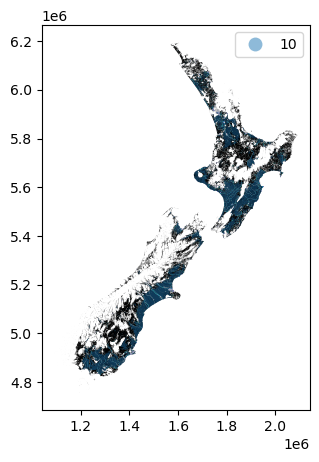

In [9]:
## PLOT
fig, ax = plt.subplots(figsize=(12,5))
aoi.plot(color='black', ax=ax)
aoi_trz.plot(column='PixelScore', ax=ax, legend=True, categorical=True, alpha=.5)
# trz.plot(ax=ax, legend=True, alpha=.5)
plt.show()

In [13]:
%%time
aoi_trz[keep_cols_catch].to_file(f"../OutputArtifacts/A10_Ecosystem15percCoverGoal/A10_Ecosystem15percCoverGoal_20240829.gpkg")

CPU times: total: 1.67 s
Wall time: 1.67 s


In [17]:
import time
for n_catch, catch in enumerate(aoi_trz.Catchment.sort_values().unique()):
    start_time = time.time()
    current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))
    print(f"\n{n_catch}_{catch.upper()}      {current_time}")

    ## Filter to each catchment
    aoi_trz = aoi_trz[aoi_trz['Catchment'] == catch][keep_cols_catch].reset_index(drop=True)

    if aoi_trz.shape[0] > 0:
        aoi_trz[keep_cols_catch].to_file(f"../OutputArtifacts/A10_Ecosystem15percCoverGoal/A10_Catchments/{str(n_catch).zfill(3)}_{catch}_Ecosystem15percCoverGoal__20240829.gpkg")

    end_time = time.time()
    time_diff = end_time - start_time
    formatted_time_diff = time.strftime("%M:%S", time.gmtime(time_diff))
    print(f"    {catch} Saved. Elapsed time: {formatted_time_diff}")


0_APARIMA      2024-09-06 12:02:34
    Aparima Saved. Elapsed time: 00:00

1_ASHBURTON-HINDS      2024-09-06 12:02:34
    Ashburton-Hinds Saved. Elapsed time: 00:00

2_AUCKLAND BASIN      2024-09-06 12:02:34
    Auckland Basin Saved. Elapsed time: 00:00

3_AUCKLAND OFFSHORE ISLANDS      2024-09-06 12:02:34
    Auckland offshore islands Saved. Elapsed time: 00:00

4_AWATERE      2024-09-06 12:02:34
    Awatere Saved. Elapsed time: 00:00

5_BANKS PENINSULA      2024-09-06 12:02:34
    Banks Peninsula Saved. Elapsed time: 00:00

6_BAY OF PLENTY OFFSHORE ISLANDS      2024-09-06 12:02:34
    Bay of Plenty offshore islands Saved. Elapsed time: 00:00

7_CATLINS      2024-09-06 12:02:34
    Catlins Saved. Elapsed time: 00:00

8_CLARENCE      2024-09-06 12:02:34
    Clarence Saved. Elapsed time: 00:00

9_CLUTHA      2024-09-06 12:02:34
    Clutha Saved. Elapsed time: 00:00

10_CONWAY      2024-09-06 12:02:34
    Conway Saved. Elapsed time: 00:00

11_COROMANDEL      2024-09-06 12:02:34
    Coro